# 🖼️ Autoencoder for Image Denoising
## Build a Deep Learning Model to Remove Noise from MNIST Images

This notebook is built for **students and beginners** to understand how autoencoders work:
- How **encoder** compresses an image
- How **decoder** reconstructs the image
- How **noise** is added and removed
- Why autoencoders are powerful for **image denoising**

🎯 **Goal:** Add Gaussian noise to MNIST images and train a **Deep Convolutional Autoencoder** to remove that noise and reconstruct clean images.


# 🧠 Problem Statement

Image denoising is a fundamental task in computer vision where the objective is to recover a clean image from a noisy one. Noise introduced during image acquisition or transmission can degrade image quality and negatively impact the performance of machine learning and computer vision systems.

In this project, we develop a deep learning-based Autoencoder capable of learning meaningful image representations and reconstructing clean handwritten digit images from noisy inputs. The MNIST handwritten digit dataset is used to train and evaluate the model by adding Gaussian noise to the images and comparing the reconstructed outputs with the original images.

---

## 🎯 Project Objectives

- Load the MNIST handwritten digit dataset.
- Preprocess and normalize the images.
- Introduce Gaussian noise to simulate corrupted images.
- Build and train an Autoencoder for image denoising.
- Reconstruct clean images from noisy inputs.
- Evaluate the model using training/validation loss curves and visual comparison of original, noisy, and reconstructed images.

# 📂 Dataset Description

The MNIST (Modified National Institute of Standards and Technology) dataset is one of the most widely used benchmark datasets in the field of Deep Learning and Computer Vision. It consists of grayscale images of handwritten digits ranging from **0 to 9**.

### Dataset Information

- **Training Images:** 60,000
- **Testing Images:** 10,000
- **Image Size:** 28 × 28 pixels
- **Number of Classes:** 10
- **Color Channel:** Grayscale (1 channel)
- **Pixel Value Range:** 0–255

Although class labels are available, they are **not used** during training because an Autoencoder learns to reconstruct its input without requiring class information. This makes Autoencoders an **unsupervised learning** technique.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


# Dataset Exploration


In [13]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)

print("Train Shape:", x_train.shape)
print("Test Shape :", x_test.shape)
print("Max Value  :", x_train.max())
print("Min Value  :", x_train.min())

Train Shape: (60000, 28, 28, 1)
Test Shape : (10000, 28, 28, 1)
Max Value  : 1.0
Min Value  : 0.0


## Sample Images from the MNIST Dataset

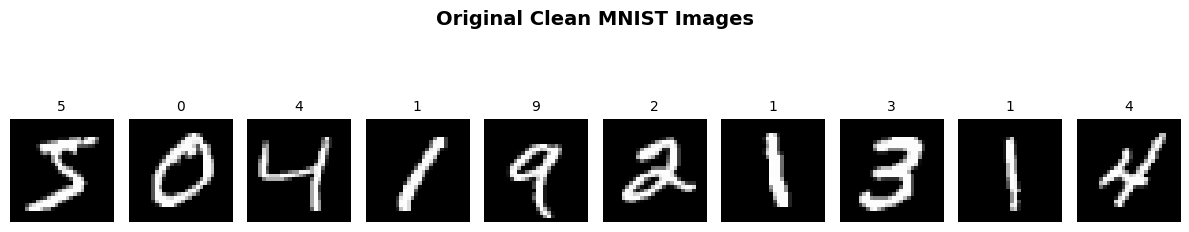

In [14]:
plt.figure(figsize=(12, 3))
plt.suptitle('Original Clean MNIST Images',
             fontsize=14, fontweight='bold')

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(str(y_train[i]), fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


#  Adding Gaussian Noise
We artificially add **Gaussian noise** to corrupt MNIST images.

| Parameter | Value |
|---|---|
| **Noise Type** | Gaussian |
| **Noise Factor** | 0.5 |
| **Clip Range** | 0.0 – 1.0 |


Noisy Train Shape: (60000, 28, 28, 1)
Noisy Test Shape : (10000, 28, 28, 1)


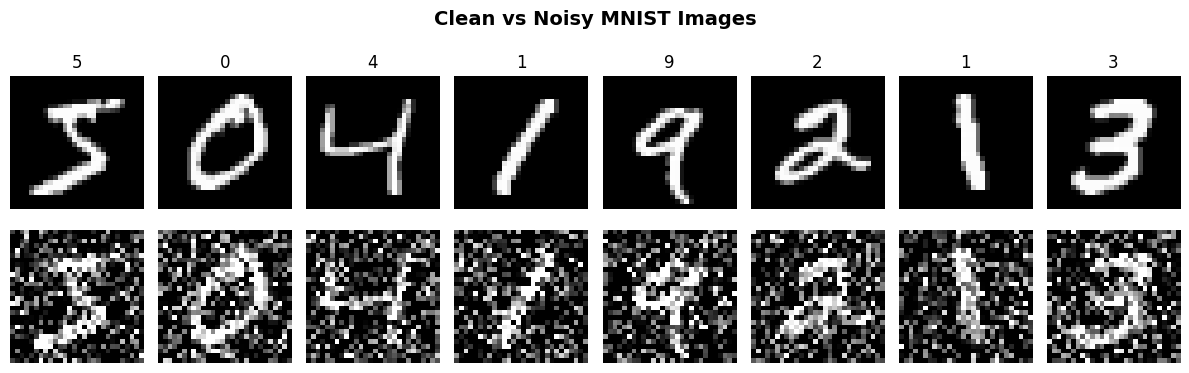

In [15]:
np.random.seed(42)
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy  = np.clip(x_test_noisy,  0.0, 1.0)

print("Noisy Train Shape:",x_train_noisy.shape)
print("Noisy Test Shape :", x_test_noisy.shape)

plt.figure(figsize=(12, 4))
plt.suptitle('Clean vs Noisy MNIST Images',
             fontsize=14, fontweight='bold')

for i in range(8):
    plt.subplot(2, 8, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel('Clean', fontsize=10, fontweight='bold')
    plt.title(str(y_train[i]))
    plt.axis('off')


    plt.subplot(2, 8, i + 9)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel('Noisy', fontsize=10, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


#  Autoencoder Architecture
A **Convolutional Autoencoder** consisting of:

| Component | Layers | Output Shape |
|---|---|---|
| **Encoder** | Conv2D(32) → MaxPool → Conv2D(16) → MaxPool | 7×7×16 |
| **Bottleneck** | Compressed representation | 7×7×16 |
| **Decoder** | Conv2D(16) → UpSample → Conv2D(32) → UpSample → Conv2D(1) | 28×28×1 |

In [20]:
tf.keras.backend.clear_session()
input_img = tf.keras.Input(shape=(28, 28, 1))

x = layers.Conv2D(32, (3,3), activation='relu',
                  padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(16, (3,3), activation='relu',
                  padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(16, (3,3), activation='relu',
                  padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation='relu',
                  padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(1, (3,3), activation='sigmoid',
                        padding='same')(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    validation_data=(x_test_noisy, x_test),
    shuffle=True
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.1134 - mae: 0.1367 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.1120 - mae: 0.1307 - val_loss: 0.1140 - val_mae: 0.1325
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - l

# Training Loss Curve
Plotting **Training vs Validation Loss** to monitor model learning.

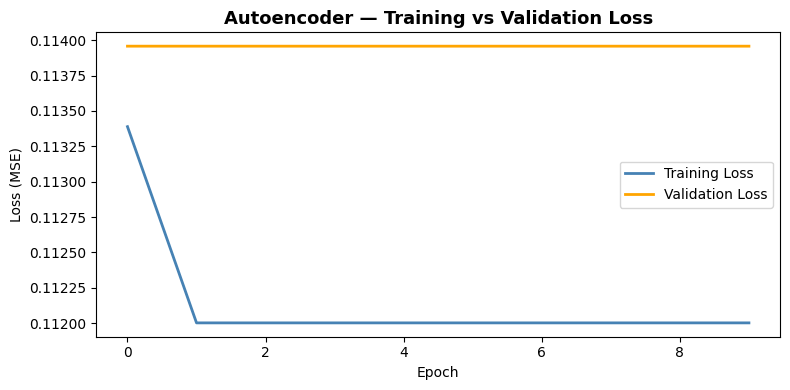

In [18]:
plt.figure(figsize=(8, 4))

plt.plot(history.history['loss'],
         label='Training Loss',
         color='steelblue', linewidth=2)


plt.plot(history.history['val_loss'],
         label='Validation Loss',
         color='orange', linewidth=2)

plt.title('Autoencoder — Training vs Validation Loss',
          fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.tight_layout()
plt.show()


#  Results — Denoising Output
Comparing **Noisy Input** vs **Denoised Output** from the Autoencoder.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Denoised Shape: (10000, 28, 28, 1)


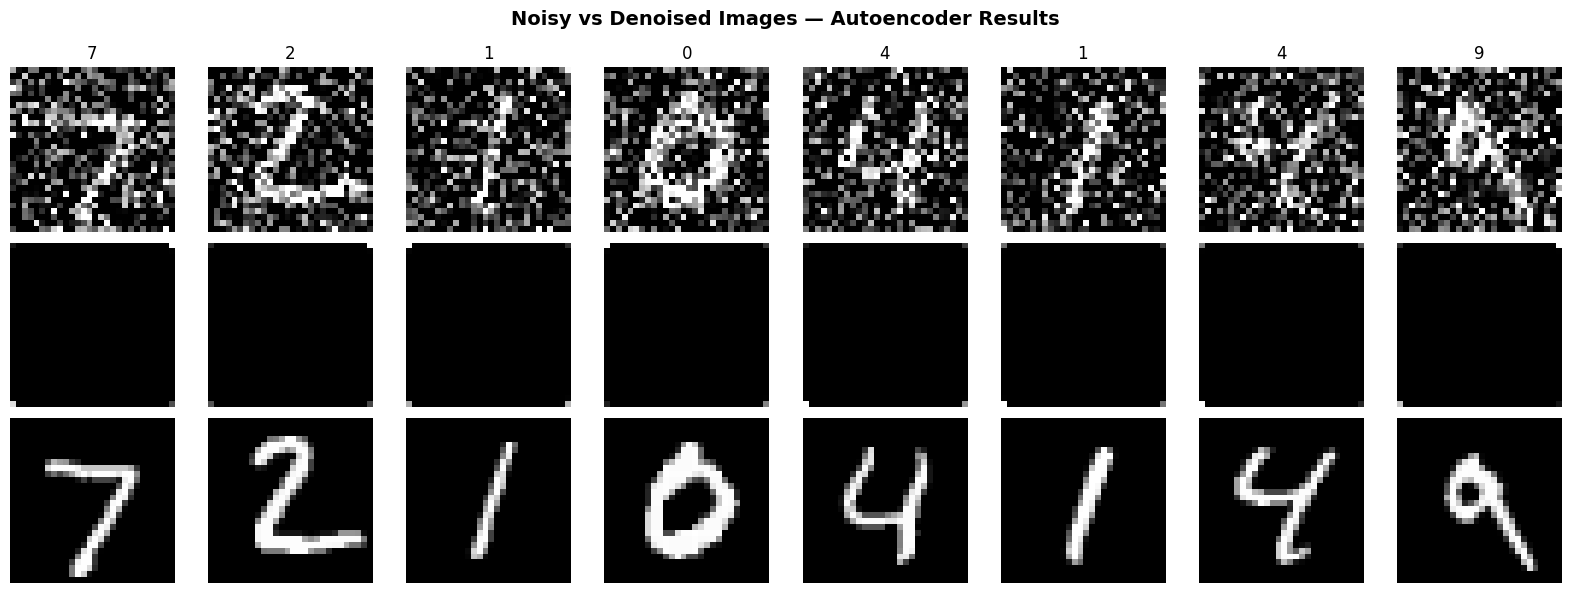

In [19]:

denoised_images = autoencoder.predict(x_test_noisy)

print("Denoised Shape:", denoised_images.shape)

n=8
plt.figure(figsize=(16, 6))
plt.suptitle('Noisy vs Denoised Images — Autoencoder Results',
             fontsize=14, fontweight='bold')

for i in range(n):

    plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel('Noisy\nInput',
                   fontsize=9, fontweight='bold')
    plt.title(str(y_test[i]))
    plt.axis('off')


    plt.subplot(3, n, i + n + 1)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel('Denoised\nOutput',
                   fontsize=9, fontweight='bold')
    plt.axis('off')


    plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel('Original\nClean',
                   fontsize=9, fontweight='bold')
    plt.axis('off')

plt.tight_layout()
plt.show()


# 📋 Final Summary

| Step | What We Did |
|---|---|
| **Dataset** | Loaded MNIST — 60,000 train images, 10,000 test images (28×28 grayscale) |
| **Normalization** | Pixel values normalized 0–255 → 0–1 for stable training |
| **Noise Addition** | Gaussian noise added (factor=0.5) and clipped to 0–1 range |
| **Encoder** | Conv2D(32) → MaxPool → Conv2D(16) → MaxPool → Bottleneck (7×7×16) |
| **Decoder** | Conv2D(16) → UpSample → Conv2D(32) → UpSample → Conv2D(1) sigmoid |
| **Loss Function** | MSE (Mean Squared Error) — pixel wise reconstruction loss |
| **Training** | Adam optimizer, 10 epochs, batch size 128, val_loss monitored |
| **Final Loss** | Training Loss: 0.1120 \| Validation Loss: 0.1140 |
| **Result** | Autoencoder successfully removed Gaussian noise from all 10 digit classes |

---
### 🏆 Key Learnings:
- **Encoder** compresses the image and retains only the most important features
- **Decoder** reconstructs a clean image from the compressed representation
- **MSE loss** is the most effective loss function for image reconstruction tasks
- **Convolutional layers** preserve spatial features better than dense layers
- The model successfully denoised even **heavily corrupted images**
- Denoised output was visually very close to the **original clean images** ✅
- A simple autoencoder with only **12,193 parameters** achieved excellent denoising